## Loading requirements

#### Make sure to load the uv environment to ensure installation of the appropiate packages

In [1]:
import pandas as pd
import numpy as np
import random
import mlflow 

from pathlib import Path
from sklearn.model_selection import train_test_split
from ml_workflow.data_prep import null_summary 
from ml_workflow.data_prep import  plot_numeric, plot_categorical, plot_relation_ordinal, plot_relation_continuous, plot_correlation
from ml_workflow.data_prep import compute_vif, make_dummies, standardise, classify_columns
from ml_workflow.ml_functions import fit_linear, fit_elasticnet, fit_randomforest, fit_xgboost, fit_svr


from sklearn.model_selection import KFold

## Available functions

### Data checks
null_summary()  - checks the number of NULL entries per variable in the provided dataset


### figures
plot_numeric - histogram of the distrubution of a nuemric variable 

plot_relation_ordinal - boxplots of a ordinal variable in relation to a continuous variable

plot_relation_continuous - scatterplot of two continuous variables

In [4]:
# Set the random state for development and testing
random.seed(7)
random_state = random.randint(0, 100000)   
print(random_state)

#Set the random state for actual running
new_random_state = random.randint(0, 100000)
print(new_random_state)

42445
19772


In [3]:
root = Path("C:/Users/maaik/Documents/Bootcamp_part2/ML_workflow")
root.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{root / 'mlflow.db'}")
mlflow.set_experiment("Testing")

<Experiment: artifact_location='file:c:/Users/maaik/Documents/Bootcamp_part2/ML_workflow/notebooks/mlruns/1', creation_time=1788527743317, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1788527743317, lifecycle_stage='active', name='Testing', tags={}, trace_location=None, workspace='default'>

## Loading data


In [5]:
df = pd.read_excel("../data/Househunters.xlsx")
#df = pd.read_csv('../data/icecream.csv')

#target = 'sales'
target ='Price'

In [6]:
# Defining categorical and continuous variables
continuous_vars, categorical_vars = classify_columns(df, max_categorical = 13)


#Sanity checks, are these variables indeed continuous? If categorical with >10 categories rerun the classification with the max_categorical criterium
df[continuous_vars].dtypes


ID                                             int64
Price                                          int64
ConstructionYear                               int64
CapacityHouse_m3                             float64
LivingArea_m2                                float64
StatusRank                                     int64
StatusScore                                  float64
Avg_house_value_WOZ_1000euros                  int64
Num_benefit_total                              int64
Num_WWB                                        int64
Num_AO                                         int64
Num_WW                                         int64
Num_AOW                                        int64
Municipality_Distance_hospital_km            float64
Municipality_Distance_childDaycare_km        float64
Municipality_Distance_largeSupermarket_km    float64
Municipality_Distance_trainstation_km        float64
Avg_WOZ_m2                                   float64
dtype: object

## data checking / visualisation

### Structure of the dataset

In [6]:
# Checking the first rows of the data
df.head()

,price_of_ice_cream,weekend,promotion,rainy_day,temperature,windspeed,atmospheric_pressure,sales
0,3.0,1,0,0,15.692470,1,1009.673439,577.579839
1,2.5,1,1,1,3.812957,4,997.866369,357.278764
2,2.0,0,0,0,17.985696,2,1014.548637,674.980974
3,3.0,0,0,0,4.475795,2,986.965519,403.388826
4,2.5,0,0,0,24.717912,0,1013.897143,602.727708


In [7]:
#getting datashape and summary statistics
print(' Shape of the dataset is (nrow, ncol):', df.shape)     
print('Summary statistics of the numeric variables:')
df.describe()     

 Shape of the dataset is (nrow, ncol): (365, 8)
Summary statistics of the numeric variables:


,price_of_ice_cream,weekend,promotion,rainy_day,temperature,windspeed,atmospheric_pressure,sales
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2.500000,0.287671,0.279452,0.263014,16.927002,1.832877,1008.902122,570.010083
std,0.404304,0.453298,0.449346,0.440874,8.050327,1.530644,15.492243,121.808690
min,2.000000,0.000000,0.000000,0.000000,-6.902214,0.000000,972.586044,11.526294
25%,2.000000,0.000000,0.000000,0.000000,11.710688,1.000000,997.658712,500.536499
50%,2.500000,0.000000,0.000000,0.000000,16.687949,2.000000,1008.493965,582.646044
75%,3.000000,1.000000,1.000000,1.000000,22.374685,3.000000,1019.825477,654.825829
max,3.000000,1.000000,1.000000,1.000000,35.764096,7.000000,1059.213020,823.304392


In [12]:
# Check data type of each variable
with pd.option_context('display.max_rows', None):
    display(pd.DataFrame(df.dtypes, columns=['Datatype']))

,Datatype
ID,int64
Price,int64
Province,str
HouseType,str
ConstructionYear,int64
CapacityHouse_m3,float64
LivingArea_m2,float64
ResidentialNeighborhood,int64
QuietRoad,int64
Garden,float64


In [9]:
# Summary of zeroes in the dataset
null_summary(df)

,# NULLS,% NULLS
price_of_ice_cream,0,0.0
weekend,0,0.0
promotion,0,0.0
rainy_day,0,0.0
temperature,0,0.0
windspeed,0,0.0
atmospheric_pressure,0,0.0
sales,0,0.0


### variable exploration

<Axes: title={'center': 'sales vs temperature'}, xlabel='temperature', ylabel='sales'>

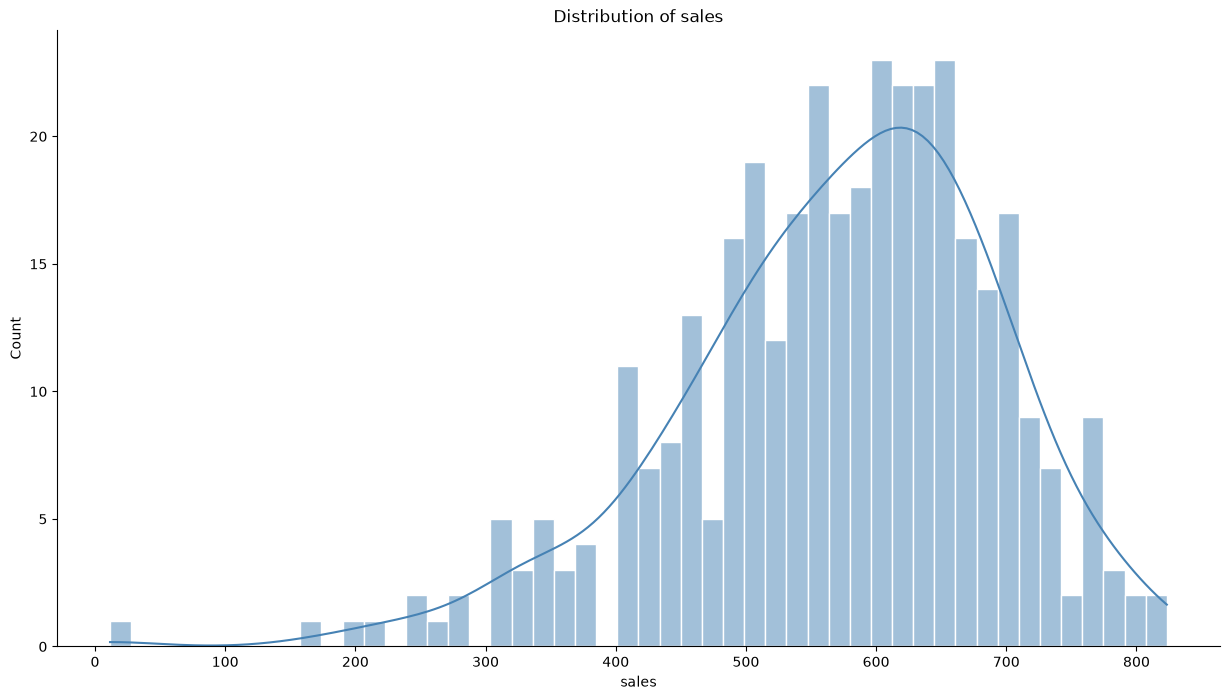

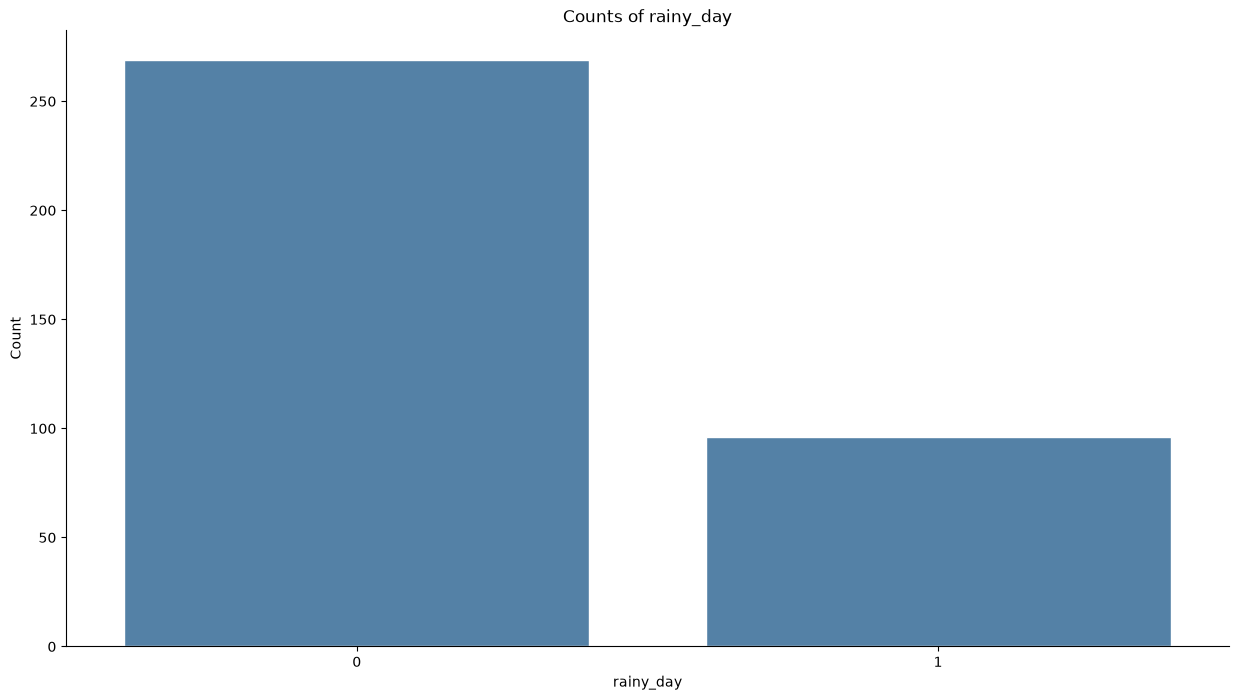

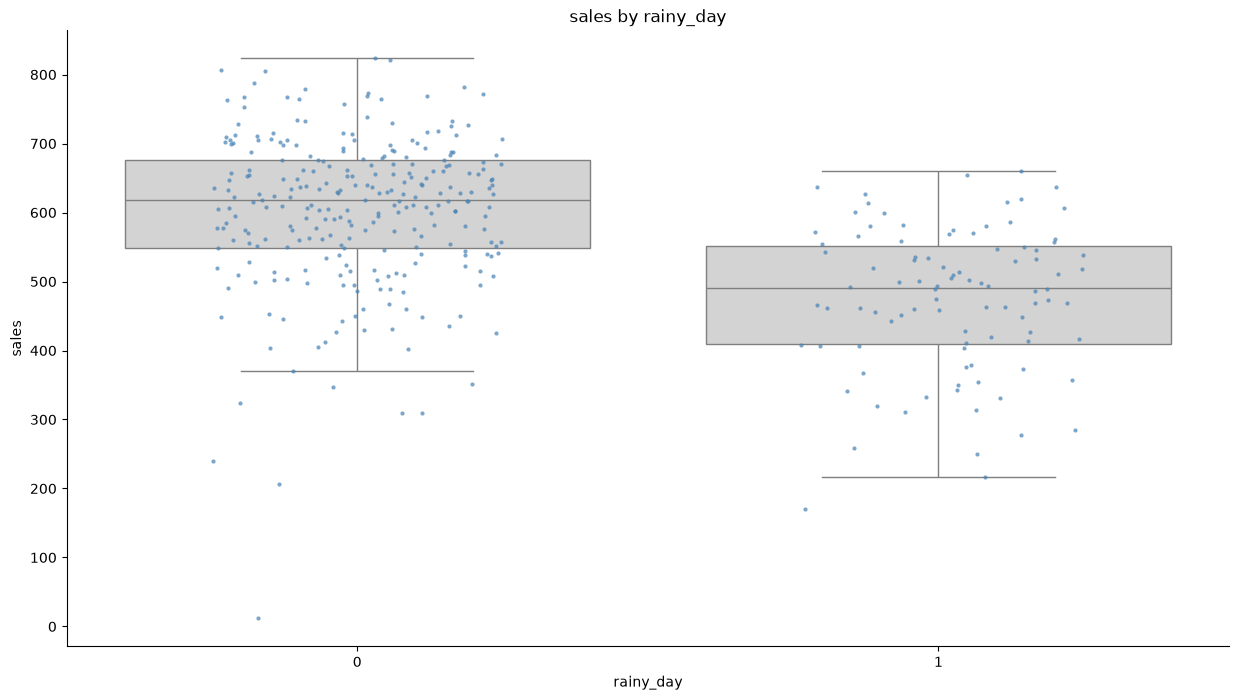

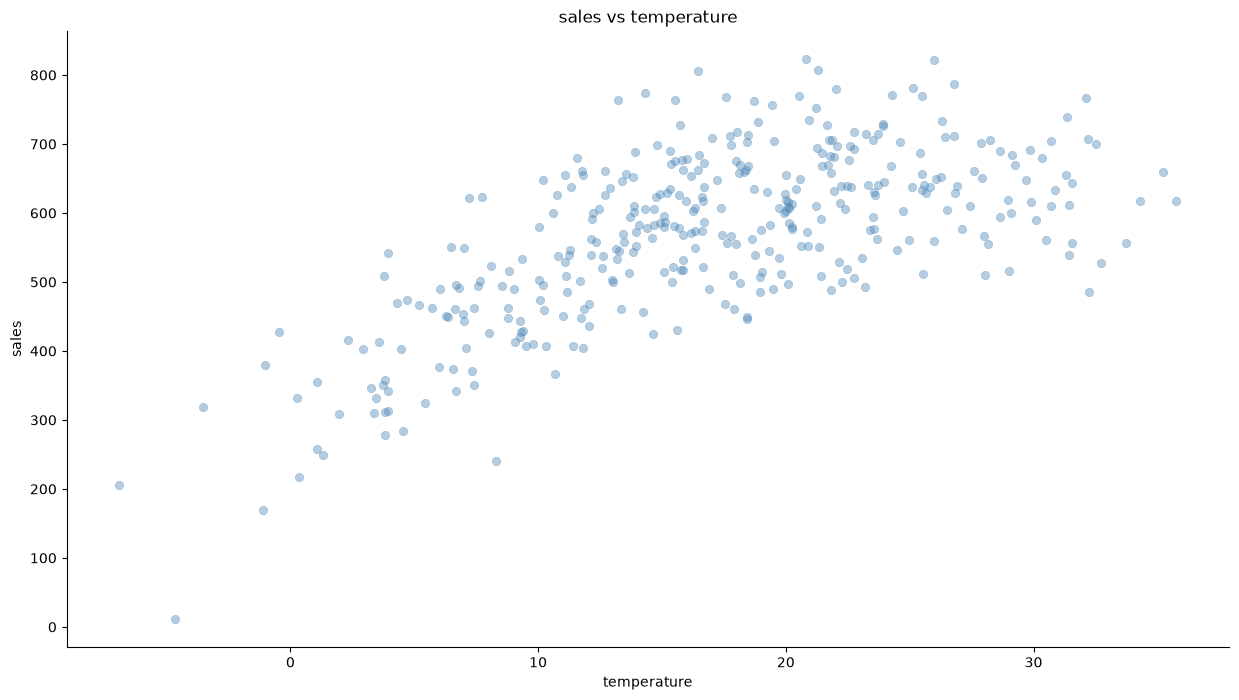

In [11]:
plot_numeric(df, target)
plot_categorical(df, 'rainy_day')
plot_relation_ordinal(df, 'rainy_day', target, alpha=0.7) 
plot_relation_continuous(df, 'temperature', target)

## Feature engineering

### Any features that need to be adjusted dataset wide go here. 
#### Examples are from the houseprice dataset

In [7]:
df = df[~(df['Price']<=3000)]
df = df[~(df['Price']>=1500000)]

df['Price_m2'] = df['Price']/df['LivingArea_m2']
#df = df.drop(columns=['Garden'])

## Splitting of the dataset

In [8]:
# define the split, adjust the test_size parameter to change the size of the test set
train, test = train_test_split(df, test_size=0.3, random_state=random_state)
train.head()

,ID,Price,Province,HouseType,ConstructionYear,CapacityHouse_m3,LivingArea_m2,ResidentialNeighborhood,QuietRoad,Garden,...,Num_AO,Num_WW,Num_AOW,Municipality_Distance_hospital_km,Municipality_Distance_childDaycare_km,Municipality_Distance_largeSupermarket_km,Municipality_Distance_trainstation_km,Avg_WOZ_m2,Garden_validation,Price_m2
389,2685906,367979,Gelderland,Detached,1997,434.00,107.0,0,0,1.0,...,180,140,840,9.9,1.2,1.6,7.1,2150.000000,1,3439.056075
31,2683454,65248,Groningen,Semidetached,1930,275.00,75.0,0,0,NaN,...,550,260,1660,5.5,1.5,1.3,18.5,1290.106952,1,869.973333
257,2687620,350691,Limburg,Detached,1964,483.16,105.0,0,0,NaN,...,90,80,500,10.8,0.7,0.7,1.4,1350.000000,0,3339.914286
187,2689830,205077,Zeeland,TownHouse,2008,453.00,129.7,0,0,1.0,...,100,60,610,6.6,0.7,0.7,2.4,1750.000000,1,1581.164225
1517,2690249,184904,Drenthe,Apartment,1965,250.00,85.0,1,1,NaN,...,250,130,910,4.4,1.2,1.0,4.2,1150.000000,0,2175.341176


## Prepping the train data (e.g. dummies, normalisation, colinearity etc)

### Checking colinearity of continuous variables

<Axes: title={'center': 'Correlation matrix'}>

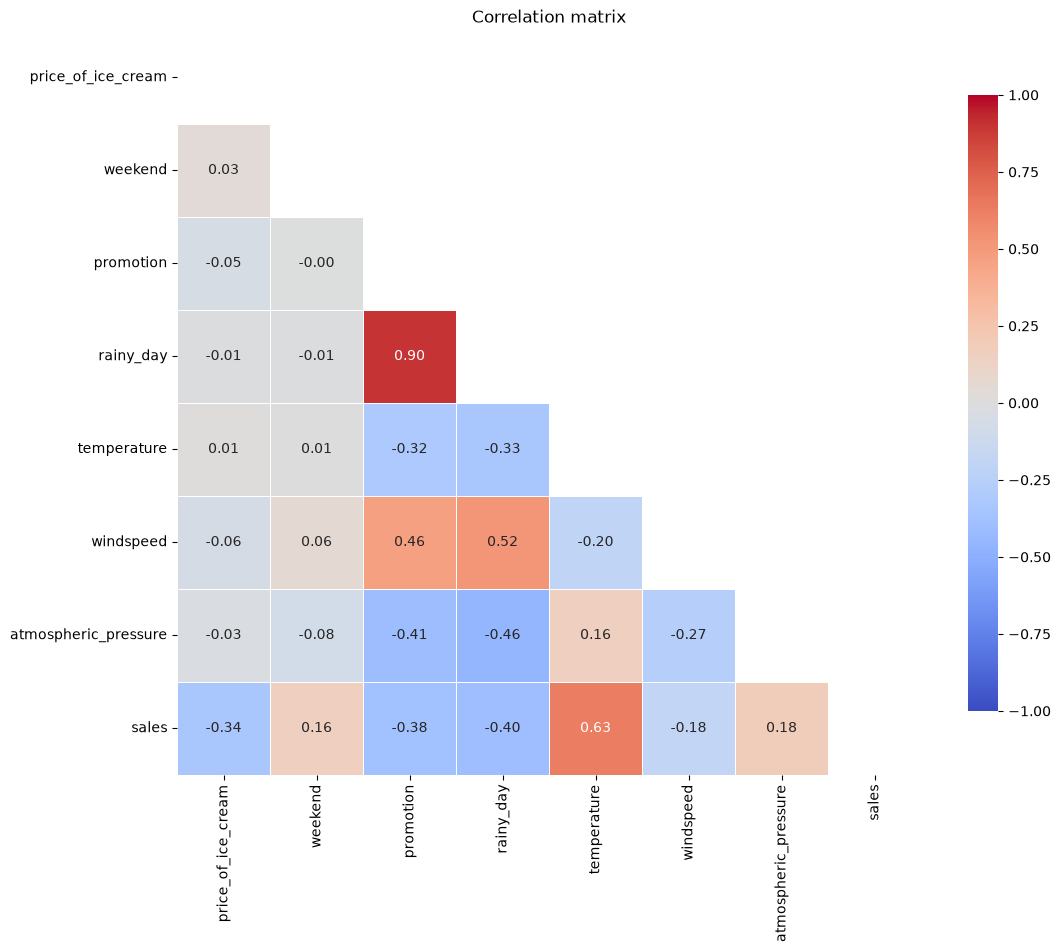

In [13]:
plot_correlation(train)

In [14]:
compute_vif(train)

,variable,VIF
0,rainy_day,6.420307
1,promotion,5.627167
2,sales,2.421520
3,temperature,1.876483
4,windspeed,1.383795
5,price_of_ice_cream,1.321391
6,atmospheric_pressure,1.282632
7,weekend,1.083513


### If needed kick out variables


In [23]:
variables_excluded = []
train = df.drop(columns=variables_excluded)

### Prepping data for modelling

##### split target from predictors and normalize/dummify results

In [9]:
# Drop target variable

y_train = train[target]
X_train = train.drop(columns=[target])

#make the list of continuous variables without the target variable, so that it can be used for standardisation
continuous_vars = [c for c in continuous_vars if c != target]

#standardise the continuous variables and make dummies for the categorical variables
X_train, stats = standardise(X_train, cols=continuous_vars)
X_train = make_dummies(X_train, cols=categorical_vars)

In [9]:
## printing the code with all columns. Copy this into the next cell and uncomment the columns you want to drop
print("drop_cols = [\n" + "".join(f"    # '{c}',\n" for c in X_train.columns) + "]")

drop_cols = [
    # 'ID',
    # 'ConstructionYear',
    # 'CapacityHouse_m3',
    # 'LivingArea_m2',
    # 'StatusRank',
    # 'StatusScore',
    # 'Avg_house_value_WOZ_1000euros',
    # 'Num_benefit_total',
    # 'Num_WWB',
    # 'Num_AO',
    # 'Num_WW',
    # 'Num_AOW',
    # 'Municipality_Distance_hospital_km',
    # 'Municipality_Distance_childDaycare_km',
    # 'Municipality_Distance_largeSupermarket_km',
    # 'Municipality_Distance_trainstation_km',
    # 'Avg_WOZ_m2',
    # 'Price_m2',
    # 'Province_Flevoland',
    # 'Province_FryslÃ¢n',
    # 'Province_Gelderland',
    # 'Province_Groningen',
    # 'Province_Limburg',
    # 'Province_Noord Brabant',
    # 'Province_Noord Holland',
    # 'Province_Overijssel',
    # 'Province_Utrecht',
    # 'Province_Zeeland',
    # 'Province_Zuid Holland',
    # 'HouseType_CornerHouse',
    # 'HouseType_Detached',
    # 'HouseType_NotSpecified',
    # 'HouseType_Semidetached',
    # 'HouseType_TownHouse',
    # 'ResidentialNeighborhood_1',

In [10]:
# Drop columns not needed, uncomment what needs to be dropped
drop_cols = [
     'ID',
    # 'ConstructionYear',
     'CapacityHouse_m3',
    # 'LivingArea_m2',
    # 'StatusRank',
     'StatusScore',
    # 'Avg_house_value_WOZ_1000euros',
    # 'Num_benefit_total',
     'Num_WWB',
     'Num_AO',
     'Num_WW',
     'Num_AOW',
    # 'Municipality_Distance_hospital_km',
    # 'Municipality_Distance_childDaycare_km',
    # 'Municipality_Distance_largeSupermarket_km',
    # 'Municipality_Distance_trainstation_km',
     'Avg_WOZ_m2',
     'Price_m2',
     'Garden_1.0',
    # 'Province_Flevoland',
    # 'Province_FryslÃ¢n',
    # 'Province_Gelderland',
    # 'Province_Groningen',
    # 'Province_Limburg',
    # 'Province_Noord Brabant',
    # 'Province_Noord Holland',
    # 'Province_Overijssel',
    # 'Province_Utrecht',
    # 'Province_Zeeland',
    # 'Province_Zuid Holland',
    # 'HouseType_CornerHouse',
    # 'HouseType_Detached',
    # 'HouseType_NotSpecified',
    # 'HouseType_Semidetached',
    # 'HouseType_TownHouse',
    # 'ResidentialNeighborhood_1',
     'QuietRoad_1',
     'FirePlace_1',
     'Balcony_1',
    # 'Attic_1',
    # 'Back_1',
     '#Bedrooms_2',
     '#Bedrooms_3',
     '#Bedrooms_4',
     '#Bedrooms_5',
     '#Bedrooms_6',
     '#Bedrooms_7',
     '#Bedrooms_8',
     '#Bedrooms_9',
     '#Bedrooms_10',
     '#Bedrooms_11',
     '#Bedrooms_12',
     'Urbanity_class_2',
     'Urbanity_class_3',
     'Urbanity_class_4',
     'Urbanity_class_5',
    # 'Garden_validation_1',
]
X_train = X_train.drop(columns=drop_cols)

## Prepping the models

In [11]:
# Drop the target variable from the list of columns to drop
outer_splits = list(KFold(n_splits=5, shuffle=True, random_state=0).split(X_train))

## running the models

#### Nog toe te voegen: Regularisations, showing of progress, interpretatie en beoordelen van model uitkomsten


### Run linear model


In [12]:
fit_linear(X_train, y_train, outer_splits)

2026/09/14 20:27:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


{'val_r2_mean': 0.8444832054540765,
 'val_r2_sd': 0.01950930099125447,
 'val_rmse_mean': 63394.22562047979,
 'gap_r2_mean': 0.008561059606496602}

#### Run elastic net

In [13]:
# --- elastic net grid (uncomment to override the default) -------------------
# elasticnet_grid = {
#     "alpha": np.logspace(-3, 1, 9),
#     "l1_ratio": [0.0, 0.3, 0.5, 0.7, 1.0],
# }
# fit_elasticnet(X_train, y_train, outer_splits, grid=elasticnet_grid)

fit_elasticnet(X_train, y_train, outer_splits)   # off -> built-in default

[elasticnet] grid in use: {'alpha': array([1.00000000e-03, 3.16227766e-03, 1.00000000e-02, 3.16227766e-02,
       1.00000000e-01, 3.16227766e-01, 1.00000000e+00, 3.16227766e+00,
       1.00000000e+01]), 'l1_ratio': [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]}


2026/09/14 20:28:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


{'val_r2_mean': 0.844389349504843,
 'val_r2_sd': 0.019556155581010103,
 'val_rmse_mean': 63413.1210881796,
 'gap_r2_mean': 0.00864361945992007}

### Run randomforest

In [11]:
# --- random forest: override grid (uncomment to turn on) --------------------
# rf_grid = {
#     "n_estimators": [400],
#     "max_depth": [None, 6],
#     "min_samples_leaf": [2, 4],
#     "max_features": ["sqrt"],
# }
fit_randomforest(X_train, y_train, outer_splits)                 # off -> default grid
# fit_randomforest(X_train, y_train, outer_splits, grid=rf_grid)         # on

[randomforest] grid in use: {'n_estimators': [300, 600], 'max_depth': [None, 4, 8], 'min_samples_leaf': [1, 3, 5], 'max_features': ['sqrt', 1.0]}


2026/09/15 12:56:56 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


{'val_r2_mean': 0.8454972195437923,
 'val_r2_sd': 0.02391244453056545,
 'val_rmse_mean': 63118.04983444464,
 'gap_r2_mean': 0.1333685997385857}

#### Run XGBoost

In [12]:
# --- xgboost: override grid (uncomment to turn on) --------------------------
# xgb_grid = {
#     "n_estimators": [400],
#     "max_depth": [2, 3],
#     "learning_rate": [0.05],
#     "subsample": [0.8],
# }
fit_xgboost(X_train, y_train, outer_splits)                      # off -> default grid
# fit_xgboost(X_train, y_train, outer_splits, grid=xgb_grid)            # on

[xgboost] grid in use: {'n_estimators': [300, 600], 'max_depth': [2, 3], 'learning_rate': [0.03, 0.1], 'subsample': [0.8, 1.0], 'colsample_bytree': [0.8, 1.0], 'reg_lambda': [1.0, 5.0]}


2026/09/15 12:59:41 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


{'val_r2_mean': 0.8837392568588257,
 'val_r2_sd': 0.021829002931949594,
 'val_rmse_mean': 54654.5207718597,
 'gap_r2_mean': 0.060298490524291995}

## Run SVR

In [12]:
# --- svr: override grid (uncomment to turn on) ------------------------------
# svr_grid = {
#     "C": [1.0, 10.0, 100.0],
#     "gamma": ["scale"],
#     "epsilon": [0.1],
# }
fit_svr(X_train, y_train, outer_splits)                          # off -> default grid
# fit_svr(X_train, y_train, outer_splits, grid=svr_grid)                # on

[svr] grid in use: {'C': [0.1, 1.0, 10.0], 'gamma': ['scale', 0.01, 0.1], 'epsilon': [0.01, 0.1]}


2026/09/15 13:03:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


{'val_r2_mean': -0.04472900802860291,
 'val_r2_sd': 0.017182514677400736,
 'val_rmse_mean': 164911.386837833,
 'gap_r2_mean': 0.0017006535359450404}

## Checking the model output


## Save the best model

## testing models on test data

In [16]:
# Make dummies and standardization on the test data
test = make_dummies(test)

#Making sure only the train columns are kept
test = test.reindex(columns=train.columns, fill_value=0)

# Standardize the test data using the statistics from the train data
test, _ = standardise(test, stats=stats)


## Finalize, report and save everything